# Time-Based EDA Take 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

#now more time-series specific things
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

system_ids = [2105, 2107, 7333, 9068] #the relevant ids
#system_id = 2105 #may have to look through them eventually
#path = f'../../../../data_ds_project/systems/prize/{system_id}/'

def systemPath(system_id):
    return f'../../../../data_ds_project/systems/prize/{system_id}/'

Want to focus on (AC) power. Should make clear whether metered (aggregate) or inverter (sample)

System **2105**: contained in file name 2105_meter_data.csv. Aggregate, is from the meter. kW.
- file: 2105_meter_data
- column: "meter_ac_output_(kwatts)_meter_150161"

System **2107**: contained in file name 2107_electrical_data_v1.csv. There are a lot of them. 
- Some are from inverters: Each is contained in a column that contains the string "_ac_power_inv_". Acc to metadata, there are  24 of them. Sample name: "inv_24_ac_power_inv_149698"
- There is an aggregate from the meter. It is an "average". Sensor name "meter_revenue_grade_ac_output (kW)". Metric id: 149578. CANNOT CURRENTLY FIND.

System **7333**: arranged yearly (each year has its own file). Columns containing power are titled "sos-[2 DIGIT NUMBER]-[3 DIGIT NUMBER]-inv[INVERTER NUMBER]-power-kw__[SENSOR ID?]"
- the only inverteter number was 1
- all are inverter data
- claims to have an aggregate meter-based measurement (in MW). Can't find it at the moment.

System **9068**: 
- inverter data split over 2 files, based on year. "9068_ac_power_data.csv" and "9068_ac_power_data_20240101_20250430.csv". All appear to be in kW.
- meter data split over 2 files, based on year. "9068_ac_power_data.csv" and "9068_meter_data_20240101_20250430.csv". Often appear to have negative numbers (why?)
    - columns = "inverter_module_1.1_ac_power_(kw)_inv_150135", "inverter_module_1.2_ac_power_(kw)_inv_150136", "inverter_module_1.3_ac_power_(kw)_inv_150137", "inverter_module_1.4_ac_power_(kw)_inv_150138", "inverter_module_2.1_ac_power_(kw)_inv_150139", "inverter_module_2.2_ac_power_(kw)_inv_150140", "inverter_module_2.3_ac_power_(kw)_inv_150141", "inverter_module_2.4_ac_power_(kw)_inv_150142",	"inverter_1_ac_power_(kw)_inv_150143", 	"inverter_2_ac_power_(kw)_inv_150144"
    
    - columns = "meter_ac_power_(kw)_meter_150150"

We will first make a dictionary that contains all this information.

# Structure of the dictionary

- Keys: system id's
- Values: tuple (meter_{system_id}, inverter_{system_id})

## Structure of the values

### meters

Each meter_{system_id} is a **list** of tuples. The list is structured as follows:

> [(file name, time column, power column),
 <br>
 ...]

The data extrated from all tuples should be CONCATENATED, as it should belong to the same meter. This happens if data is stretched across several files.

### inverters

Each inverter_{system_id} is a **list**. The list is structured as follows:

> [ [inverter 1 information],
<br>
[inverter 2 information],
<br>
...]

[inverter *n* information] is a **list**. It is a list of tuples, structured as follows:

> [(file name, time column, power column),
 <br>
 ...]

The data extrated from all tuples should be CONCATENATED, as it should belong to the same inverter.

In [2]:
#information about accessing the data
#only aggregate meters will be considered
meter_2105 = [('2105_meter_data.csv', 'measured_on', 'meter_ac_output_(kwatts)_meter_150161')]
inverter_2105 =[] #only has data in kWh, so power data would have to be approximated.

meter_2107 = [] #cannot currently find.
#build the inverter list. There are a LOT of columns of inverter data.
inverter_2107 = []
df = pd.read_csv(systemPath(2107)+'2107_electrical_data_v1.csv') #won't need this again in the short term
cols = list(df.columns) #get column names so we can pick out the relevant columns -- those that contain "_ac_power_inv_"
relevant_columns =[] #each entry will contain the column name corresponding to the data of an inverter
for col in cols:
    if "_ac_power_inv_" in col:
        relevant_columns.append(col)
for col in relevant_columns: #now we append to the inverter list
    inverter_2107.append([('2107_electrical_data_v1.csv', "measured_on", col)])

meter_7333 = [] #no data
inverter_7333 = []   #utc_measured_on
#will assume all the files have the same column names
df = pd.read_csv(systemPath(7333)+'7333_5_min_ac_20160101_20161231.csv')
cols = list(df.columns) #get column names so we can pick out the relevant columns -- those that contain "_ac_power_inv_"
relevant_columns =[] #each entry will contain the column name corresponding to the data of an inverter
for col in cols:
    if "power" in col:
        relevant_columns.append(col)
folder_path = Path(systemPath(7333))
for col in relevant_columns: #now we append to the inverter list
    #have to loop through all the file names
    invlist = []
    for file in folder_path.glob('*_ac_*'):
        invlist.append((file.name, 'utc_measured_on', col))
    inverter_7333.append(invlist)


meter_9068 = [
    ("9068_ac_power_data.csv",
     "measured_on",
     "meter_ac_power_(kw)_meter_150150"),
    ("9068_meter_data_20240101_20250430.csv",
     "measured_on",
     "meter_ac_power_(kw)_meter_150150")
]
#define inverter_9068 list
inverter_9068 = []
for inverter in ["inverter_module_1.1_ac_power_(kw)_inv_150135", "inverter_module_1.2_ac_power_(kw)_inv_150136", "inverter_module_1.3_ac_power_(kw)_inv_150137", "inverter_module_1.4_ac_power_(kw)_inv_150138", "inverter_module_2.1_ac_power_(kw)_inv_150139", "inverter_module_2.2_ac_power_(kw)_inv_150140", "inverter_module_2.3_ac_power_(kw)_inv_150141", "inverter_module_2.4_ac_power_(kw)_inv_150142",	"inverter_1_ac_power_(kw)_inv_150143", 	"inverter_2_ac_power_(kw)_inv_150144"]:
    #inverter is a column name
    #note that to get complete information, the data in the two invlists will have to be combined
    invlist = [('9068_ac_power_data.csv', "measured_on", inverter), ('9068_ac_power_data_20240101_20250430.csv', "measured_on", inverter)]
    inverter_9068.append(invlist)



#finally, define the dictionary!
systems = {
    2105: (meter_2105, inverter_2105),
    2107: (meter_2107, inverter_2107),
    7333: (meter_7333, inverter_7333),
    9068: (meter_9068, inverter_9068)
}

# Combining and cleaning data


In [83]:
def combine_and_clean(system_id, locations):
    """Combine all the data of a given inverter or meter into 1 dataframe

    Args:
        system_id (string or integer): system_id of the system being worked with. Used for file path.
        locations (list of 3-tuples): each tuple is (file name, time column title, power column title)

    Output:
        dataframe of combined information. 
        Two columns:
        'time' (datetime type)
        'power' (float, in kW)

        
    Along the way, will:
    - remove all data that has power entry < 1% of max value (industry standard is 1% of capacity, but that is unknown)
    - make time a datetime object (not string)
    - sort ascending by time

    """
    df = pd.DataFrame(columns = ['time_string', 'power'])
    #we will want to add items from each tuple! (aka file)
    dfs = [] #make a list of dataframes that will all be concatenated later
    for file in locations:
        df2 = pd.read_csv(systemPath(system_id)+file[0], usecols=[file[1],file[2]])
        #rename columns for consistency
        df2.columns = ['time_string', 'power']
        #mild cleaning to reduce size -- remove all 0's. 
        df2 = df2.loc[df2['power']>=0.0001]

        dfs.append(df2)

    df = pd.concat(dfs, ignore_index=True)

    #make a new column called time that is a datetime object

    df['time'] = pd.to_datetime(df['time_string'])
    df = df[['time','power']]
    df.sort_values(by = 'time', inplace= True)

    max_val = df['power'].max()
    df = df.loc[df['power']> (max_val*0.01)]

    return df


In [104]:
#test the combine_and_clean function
testing = combine_and_clean(9068, inverter_9068[0])
#testing.describe()
testing

,time,power
0,2017-08-24 11:10:00,193.9
1,2017-08-24 11:15:00,254.9
2,2017-08-24 11:20:00,253.6
3,2017-08-24 11:25:00,184.0
4,2017-08-24 11:30:00,222.5
...,...,...
342121,2025-04-30 14:00:00,405.9
342122,2025-04-30 14:05:00,405.4
342123,2025-04-30 14:10:00,405.9
342124,2025-04-30 14:15:00,404.7


#### To quickly plot data

In [86]:
def plot_series(data, start = 0, end = None, xlabel = "Time"):
    """plots the time series data

    Args:
        data (dataframe): column 1: time, column 2: power
        start (int): first entry to plot
        end (int): index of last entry to plot + 1 (if no input, will be end of dataframe)
        xlabel (string): what goes on x-axis.
    """
    if end == None:
        end = len(data)
    plt.plot(data['time'], data['power'])
    plt.xlabel = xlabel
    plt.ylabel = 'Power (kW)'

    plt.show()


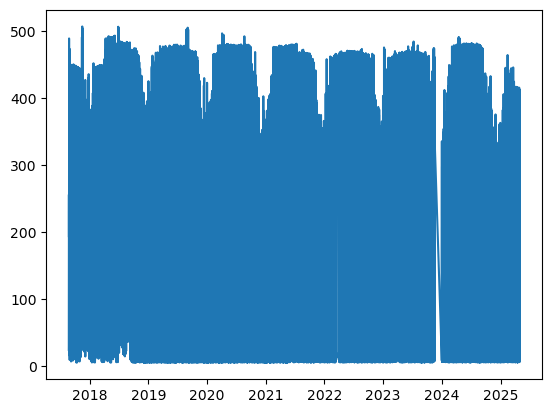

In [87]:
plot_series(testing)

#### Averaging
There are too many data points to understand everything. We will average over the span of a day.

In [96]:
def daily_average(data):
    daily = data.groupby(data['time'].dt.date)['power'].mean()
    daily_df = daily.to_frame(name = 'power')
    daily_df = daily_df.reset_index()
    daily_df = daily_df.rename(columns={'index':'date'})
    return daily_df

,time,power
0,2017-08-24,203.377193
1,2017-08-25,225.305882
2,2017-08-28,358.306410
3,2017-08-29,369.557246
4,2017-08-30,357.706306
...,...,...
2646,2025-04-26,328.347403
2647,2025-04-27,237.132000
2648,2025-04-28,207.632653
2649,2025-04-29,335.083125


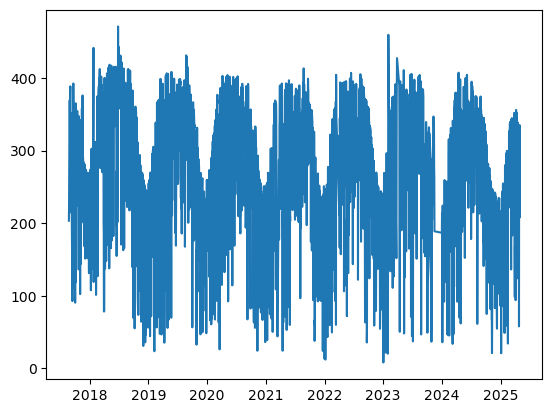

In [98]:
#test daily_avg
daily_avg = daily_average(testing)
display(daily_avg)
plot_series(daily_avg)

In [3]:
#test the cleaniny.py file
from cleaning import Clean
obj_9068 = Clean(9068, '../../../../data_ds_project/systems/prize/')
cleaned_test = obj_9068.combine_and_clean(inverter_9068[0])
display(cleaned_test)
averages_test = obj_9068.daily_average(cleaned_test)
display(averages_test)

,time,power
0,2017-08-24 11:10:00,193.9
1,2017-08-24 11:15:00,254.9
2,2017-08-24 11:20:00,253.6
3,2017-08-24 11:25:00,184.0
4,2017-08-24 11:30:00,222.5
...,...,...
342121,2025-04-30 14:00:00,405.9
342122,2025-04-30 14:05:00,405.4
342123,2025-04-30 14:10:00,405.9
342124,2025-04-30 14:15:00,404.7


,time,power
0,2017-08-24,203.377193
1,2017-08-25,225.305882
2,2017-08-28,358.306410
3,2017-08-29,369.557246
4,2017-08-30,357.706306
...,...,...
2646,2025-04-26,328.347403
2647,2025-04-27,237.132000
2648,2025-04-28,207.632653
2649,2025-04-29,335.083125


In [4]:
obj_9068.write_to_file(averages_test,"inverter")

000
